# Ejemplo 2: Agrupamiento de Estaciones Meteorológicas (Clustering Jerárquico)
Este notebook desarrolla de manera completa y consistente la técnica de **Aprendizaje No Supervisado: Agrupamiento Jerárquico** (Hierarchical Clustering).

### **Objetivo**: 
Agrupar estaciones meteorológicas simuladas de distintas regiones geográficas del Perú según sus patrones de **Temperatura Media**, **Humedad Relativa** y **Precipitación Anual**, visualizando su afinidad mediante un **Dendrograma** y entrenando un modelo de clustering aglomerativo.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist

import warnings
warnings.filterwarnings('ignore')


### 1. Preparación y Carga de Datos
Simulamos un conjunto de datos meteorológicos representativos de diversas regiones climáticas del país para poder observar agrupaciones claras.


In [2]:
# Definimos estaciones meteorológicas con sus características físicas:
# [Temperatura_Media (C°), Humedad_Relativa (%), Precipitación_Anual (mm)]
datos_estaciones = np.array([
    [26, 85, 2200],  # Iquitos (Selva)
    [27, 88, 2400],  # Pucallpa (Selva)
    [25, 82, 1900],  # Tarapoto (Selva)
    [12, 45, 800],   # Huancayo (Sierra)
    [10, 40, 700],   # Cusco (Sierra)
    [9,  42, 600],   # Puno (Sierra)
    [22, 60, 50],    # Piura (Costa Norte - Seco/Cálido)
    [24, 62, 80],    # Tumbes (Costa Norte)
    [18, 80, 15],    # Lima (Costa Centro - Húmedo/Templado)
    [17, 82, 10],    # Callao (Costa Centro)
    [21, 55, 300],   # Chanchamayo (Valle)
    [20, 58, 400],   # Quillabamba (Valle)
    [14, 25, 10],    # Desierto Nazca (Árido/Seco)
    [15, 28, 5],     # Desierto Sechura (Árido/Seco)
])

nombres_estaciones = [
    'Iquitos (Selva A)', 'Pucallpa (Selva B)', 'Tarapoto (Selva C)',
    'Huancayo (Sierra A)', 'Cusco (Sierra B)', 'Puno (Sierra C)',
    'Piura (Costa Norte A)', 'Tumbes (Costa Norte B)',
    'Lima (Costa Centro A)', 'Callao (Costa Centro B)',
    'Chanchamayo (Valle A)', 'Quillabamba (Valle B)',
    'Nazca (Desierto A)', 'Sechura (Desierto B)'
]

df = pd.DataFrame(datos_estaciones, columns=['Temp_Media', 'Humedad_Relativa', 'Precipitacion_Anual'], index=nombres_estaciones)
df.head(14)


,Temp_Media,Humedad_Relativa,Precipitacion_Anual
Iquitos (Selva A),26,85,2200
Pucallpa (Selva B),27,88,2400
Tarapoto (Selva C),25,82,1900
Huancayo (Sierra A),12,45,800
Cusco (Sierra B),10,40,700
Puno (Sierra C),9,42,600
Piura (Costa Norte A),22,60,50
Tumbes (Costa Norte B),24,62,80
Lima (Costa Centro A),18,80,15
Callao (Costa Centro B),17,82,10


### 2. Preprocesamiento: Escalado Estándar
**Justificación:** Al igual que K-Means, el clustering jerárquico utiliza distancias geométricas (típicamente euclidianas) para calcular la similitud. Como la precipitación anual alcanza valores de 2400 mm y la temperatura solo llega a 30°C, es obligatorio escalar las variables para que tengan media 0 y varianza 1.


In [3]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

df_scaled_pd = pd.DataFrame(df_scaled, columns=df.columns, index=df.index)
df_scaled_pd.head(5)


,Temp_Media,Humedad_Relativa,Precipitacion_Anual
Iquitos (Selva A),1.293949,1.234865,1.844353
Pucallpa (Selva B),1.468134,1.379737,2.086462
Tarapoto (Selva C),1.119763,1.089992,1.481189
Huancayo (Sierra A),-1.144647,-0.696767,0.149589
Cusco (Sierra B),-1.493018,-0.938221,0.028534


### 3. Generación del Dendrograma (Enlace Jerárquico)
El dendrograma representa de forma gráfica cómo se van fusionando los clusters en cada nivel.
Evaluamos la matriz de enlace (`linkage`) usando diferentes criterios de distancia (métodos de enlace):
- `ward`: Minimiza la varianza interna de los clusters resultantes.
- `complete`: Distancia máxima entre los elementos de los dos clusters.
- `single`: Distancia mínima entre los elementos de los dos clusters.


In [4]:
# Generamos enlaces usando criterios Ward, Complete y Single
Z_ward = linkage(df_scaled, method='ward')
Z_complete = linkage(df_scaled, method='complete')

# Coeficiente de correlación cofenética (Mide qué tan fiel es el dendrograma a las distancias originales)
coph_ward, coph_dists_ward = cophenet(Z_ward, pdist(df_scaled))
coph_comp, coph_dists_comp = cophenet(Z_complete, pdist(df_scaled))

print(f"Correlación Cofenética (Ward): {coph_ward:.4f}")
print(f"Correlación Cofenética (Complete): {coph_comp:.4f}")


Correlación Cofenética (Ward): 0.9105
Correlación Cofenética (Complete): 0.9111


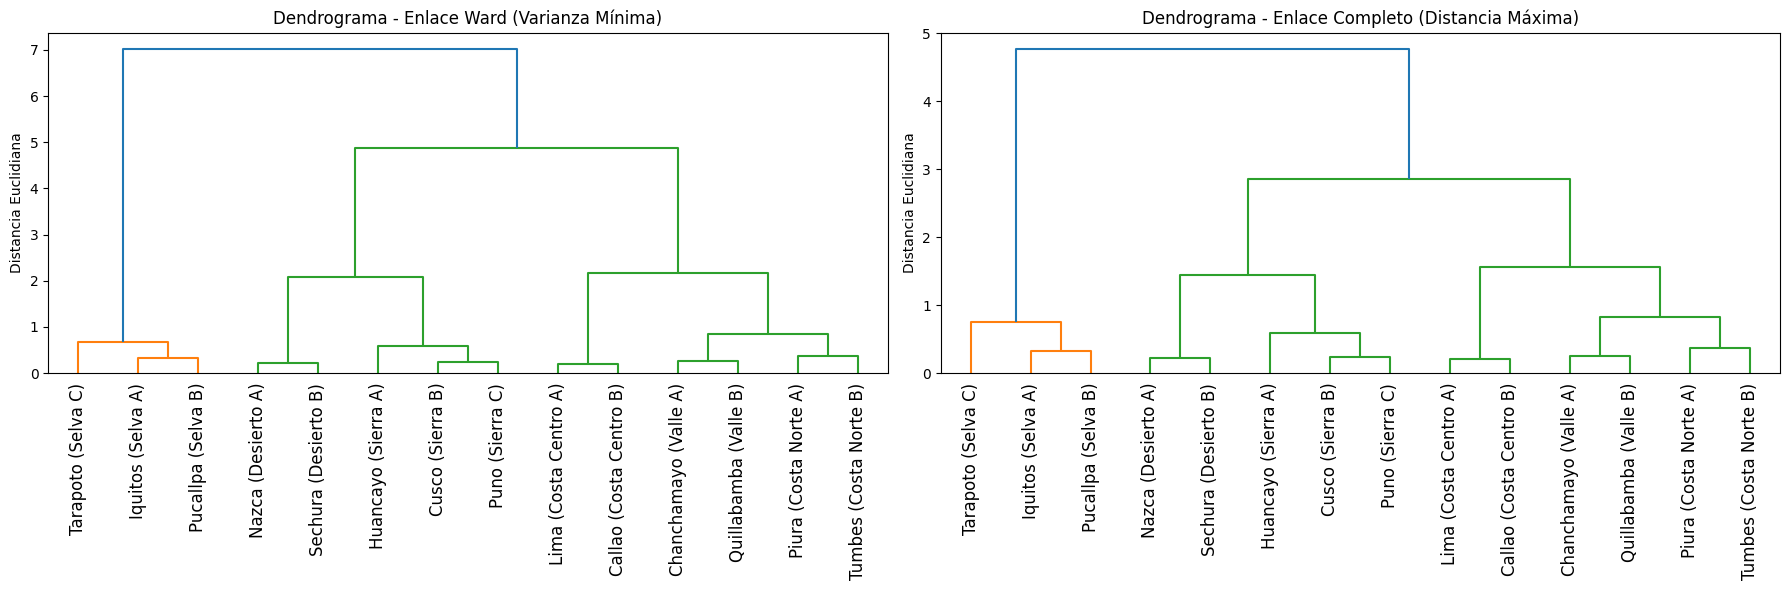

In [5]:
# Graficar Dendrogramas Comparativos
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

dendrogram(Z_ward, labels=df.index, ax=axes[0])
axes[0].set_title('Dendrograma - Enlace Ward (Varianza Mínima)')
axes[0].set_ylabel('Distancia Euclidiana')
axes[0].tick_params(axis='x', rotation=90)

dendrogram(Z_complete, labels=df.index, ax=axes[1])
axes[1].set_title('Dendrograma - Enlace Completo (Distancia Máxima)')
axes[1].set_ylabel('Distancia Euclidiana')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


### 4. Entrenamiento del Modelo Aglomerativo (AgglomerativeClustering)
Al mirar el dendrograma de Ward, podemos ver que si trazamos un corte horizontal en una distancia euclidiana de **4.0**, obtenemos **4 clusters** muy bien definidos (Selva, Sierra, Costa/Valles y Desierto/Costa Árida).


In [6]:
# Instanciamos el clasificador de clustering jerárquico
# Asignamos n_clusters=4 según el análisis del dendrograma
num_clusters = 4
model_hc = AgglomerativeClustering(n_clusters=num_clusters, metric='euclidean', linkage='ward')
df['Cluster'] = model_hc.fit_predict(df_scaled)

# Agrupamos y caracterizamos los clusters resultantes
df.groupby('Cluster').mean()


,Temp_Media,Humedad_Relativa,Precipitacion_Anual
Cluster,,,
0,12.00,36.00,423.000000
1,26.00,85.00,2166.666667
2,21.75,58.75,207.500000
3,17.50,81.00,12.500000


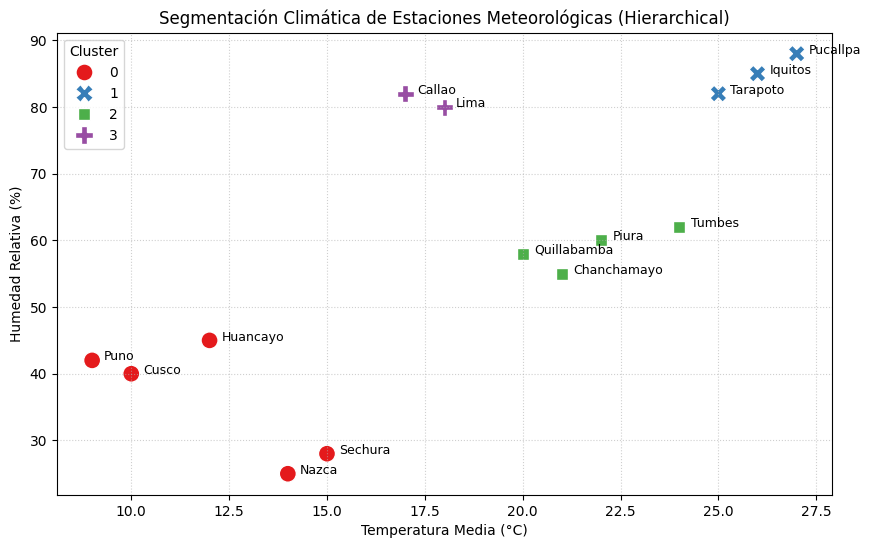

In [7]:
# Graficar la segmentación en un Scatter Plot de 2D
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, x='Temp_Media', y='Humedad_Relativa', 
    hue='Cluster', palette='Set1', s=150, style='Cluster'
)

# Colocar nombres de las ciudades sobre los puntos
for i, txt in enumerate(df.index):
    plt.annotate(txt.split(' ')[0], (df['Temp_Media'].iloc[i]+0.3, df['Humedad_Relativa'].iloc[i]), fontsize=9)

plt.title('Segmentación Climática de Estaciones Meteorológicas (Hierarchical)')
plt.xlabel('Temperatura Media (°C)')
plt.ylabel('Humedad Relativa (%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


## 5. Banco de Preguntas y Respuestas Teórico-Prácticas (Nivel Examen)

### **Pregunta 1 (Lectura del Dendrograma):**
**Enunciado:** Describa matemáticamente cómo se define la altura de los enlaces verticales en un Dendrograma y explique cómo se utiliza este gráfico para tomar la decisión de cuántos clusters elegir.

**Respuesta Correcta y Justificación:**
La altura de las líneas verticales en el dendrograma representa la **distancia de fusión** (la distancia euclidiana o disimilitud calculada por el método de enlace elegido, ej: Ward) en la cual dos clusters se unieron.
*   **Criterio de Elección de Clusters:** Para decidir el número de clusters, se busca la **línea horizontal de mayor longitud vertical que no sea cruzada por ninguna unión horizontal** (el espacio vertical vacío más grande). Se traza una línea de corte horizontal a esa altura. El número de intersecciones con las líneas verticales del dendrograma indicará el número óptimo de clusters ($K$).

---

### **Pregunta 2 (Criterios de Enlace):**
**Enunciado:** Compare las ventajas y desventajas del criterio de enlace **Ward (Minimización de Varianza)** frente al enlace **Single (Distancia Mínima)**. ¿Qué efecto indeseado suele producir el enlace Single en datasets ruidosos?

**Respuesta Correcta y Justificación:**
- **Enlace Ward:** Minimiza el aumento en la suma de cuadrados de las distancias dentro de los clusters al fusionarse. *Pro:* Genera clusters de tamaño relativamente igual y muy compactos (forma esférica). *Contra:* Asume que los clusters tienen estructura esférica.
- **Enlace Single (Vecino más cercano):** Define la distancia entre dos clusters como el valor mínimo entre cualquier punto de A y cualquier punto de B. *Pro:* Puede capturar formas no esféricas complejas (elongadas). *Contra:* Es altamente propenso al fenómeno de **Encadenamiento (Chaining)**. Si hay outliers o ruido que conecta dos clusters separados, el enlace Single los unirá prematuramente a través de ese "puente" de ruido, creando un único cluster alargado y deforme.

---

### **Pregunta 3 (Métrica Cofenética):**
**Enunciado:** ¿Qué representa el **Coeficiente de Correlación Cofenética** obtenido en el notebook y qué utilidad tiene para el analista de datos al elegir el método de enlace?

**Respuesta Correcta y Justificación:**
El Coeficiente de Correlación Cofenética mide qué tan fielmente la estructura de árbol del dendrograma conserva las **distancias euclidianas originales** de la matriz de datos original en el espacio de características. 
- Toma valores entre $0$ y $1$. Un valor cercano a $1$ indica que el dendrograma representa fielmente las distancias originales.
- **Utilidad:** Sirve para evaluar de forma cuantitativa y objetiva cuál método de enlace (ej: complete vs. average vs. ward) preserva mejor la topología de los datos crudos, ayudando al analista a seleccionar el modelo más realista.
